# Notebook 03: 4-Way Hybrid Trend Prediction Pipeline & Evaluation Benchmark

This notebook provides an end-to-end evaluation suite for the **Hybrid Time-Series & Gradient Boosting Framework**:
- **4 Competing Architectures**:
  1. `SARIMA + LightGBM` (Baseline Univariate Time-Series + GBDT)
  2. `SARIMAX + LightGBM` (Exogenous Engagement Time-Series + GBDT)
  3. `SARIMA + XGBoost` (Univariate Time-Series + Regularized GBDT)
  4. `SARIMAX + XGBoost` (Exogenous Feature-Augmented + XGBoost)
- **Strict Chronological Evaluation**: Temporal 70/20/10 train/val/test splits without data leakage.
- **Comprehensive Metric Suite**: ROC-AUC, PR-AUC, Macro-F1, Matthews Correlation Coefficient (MCC), Brier Score, and Recall@Top-K%.
- **Early Warning & Lifespan Horizons**: 24-hour persistence and decay outlook.

--- 
## 1. Environment Setup & Project Root Path Auto-Detection

In [11]:
import sys
import os

# Automatically ensure project root is current working directory
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

if '.' not in sys.path:
    sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.file_io import load_yaml, load_dataframe
from src.stage_08_prediction_models.pipeline import PredictionPipeline

config = load_yaml('configs/config.yaml')
print(f"Active Project Root: {os.getcwd()}")
print("Prediction pipeline modules successfully initialized.")

Active Project Root: c:\Users\THANH CONG\Documents\social_listening
Prediction pipeline modules successfully initialized.


--- 
## 2. Load or Execute Prediction & Benchmark Pipeline

> **Efficiency Note**: By default, this cell runs in **Fast Mode** (`RERUN_PIPELINE = False`) to instantly load precomputed predictions in under 1 second. Set `RERUN_PIPELINE = True` if you wish to re-train the models from scratch.

In [12]:
RERUN_PIPELINE = False

comparison_path = 'data/08_predictions/model_comparison_results.csv'
test_pred_path = 'data/08_predictions/all_test_predictions.parquet'
top_trending_path = 'data/08_predictions/predicted_trending_topics.csv'

if RERUN_PIPELINE or not os.path.exists(comparison_path):
    print("Executing full Prediction & Model Comparison Pipeline...")
    pipeline = PredictionPipeline(config.get('stage_08_prediction_models', {}))
    train_df = load_dataframe('data/07_splits/train.parquet')
    valid_df = load_dataframe('data/07_splits/valid.parquet')
    test_df = load_dataframe('data/07_splits/test.parquet')
    comp_df, all_metrics, test_preds = pipeline.run_model_comparison(train_df, valid_df, test_df)
    print("Pipeline training & 4-way evaluation complete!")
else:
    print(f"Loading precomputed comparison results from: {comparison_path}")
    comp_df = pd.read_csv(comparison_path)
    test_preds = load_dataframe(test_pred_path)
    print(f"Loaded {len(comp_df)} benchmarked models and {len(test_preds)} test prediction instances.")

Loading precomputed comparison results from: data/08_predictions/model_comparison_results.csv
Loaded 4 benchmarked models and 128 test prediction instances.


--- 
## 3. Multi-Metric Benchmark Comparison Table

Evaluating models across discrimination (ROC-AUC, PR-AUC), threshold balance (Macro-F1, MCC), probability calibration (Brier Score), and surveillance utility (Recall@10%, Recall@20%).

In [13]:
# Highlight highest scores for benefit metrics and lowest for cost metrics (brier_score)
display_cols = ['model_name', 'macro_f1', 'f1_score', 'roc_auc', 'pr_auc', 'mcc', 'brier_score', 'recall_at_10pct', 'recall_at_20pct']
valid_cols = [c for c in display_cols if c in comp_df.columns]

styled_table = comp_df[valid_cols].copy()
print("=== 4-Way Model Benchmark Comparison Summary ===")
max_cols = [c for c in ['macro_f1', 'f1_score', 'roc_auc', 'pr_auc', 'mcc', 'recall_at_10pct', 'recall_at_20pct'] if c in styled_table.columns]
min_cols = [c for c in ['brier_score'] if c in styled_table.columns]

styler = styled_table.style
if max_cols:
    styler = styler.highlight_max(subset=max_cols, color='#43a156')
if min_cols:
    styler = styler.highlight_min(subset=min_cols, color='#43a156')
styler = styler.format(precision=4)
styler


=== 4-Way Model Benchmark Comparison Summary ===


,model_name,macro_f1,f1_score,roc_auc,pr_auc,mcc,brier_score,recall_at_10pct,recall_at_20pct
0,SARIMA + LightGBM,0.3298,0.6597,0.6348,0.6020,0.0000,0.2854,0.1429,0.2540
1,SARIMAX + LightGBM,0.3298,0.6597,0.6348,0.6020,0.0000,0.2854,0.1429,0.2540
2,SARIMA + XGBoost,0.3816,0.6522,0.5961,0.5574,0.0306,0.2569,0.0952,0.2381
3,SARIMAX + XGBoost,0.3816,0.6522,0.5961,0.5574,0.0306,0.2569,0.0952,0.2381


--- 
## 4. Visual Model Comparison Dashboards (ROC, PR, Radar & Calibration)

Visualizing performance across all 4 architectures from `docs/images/`.


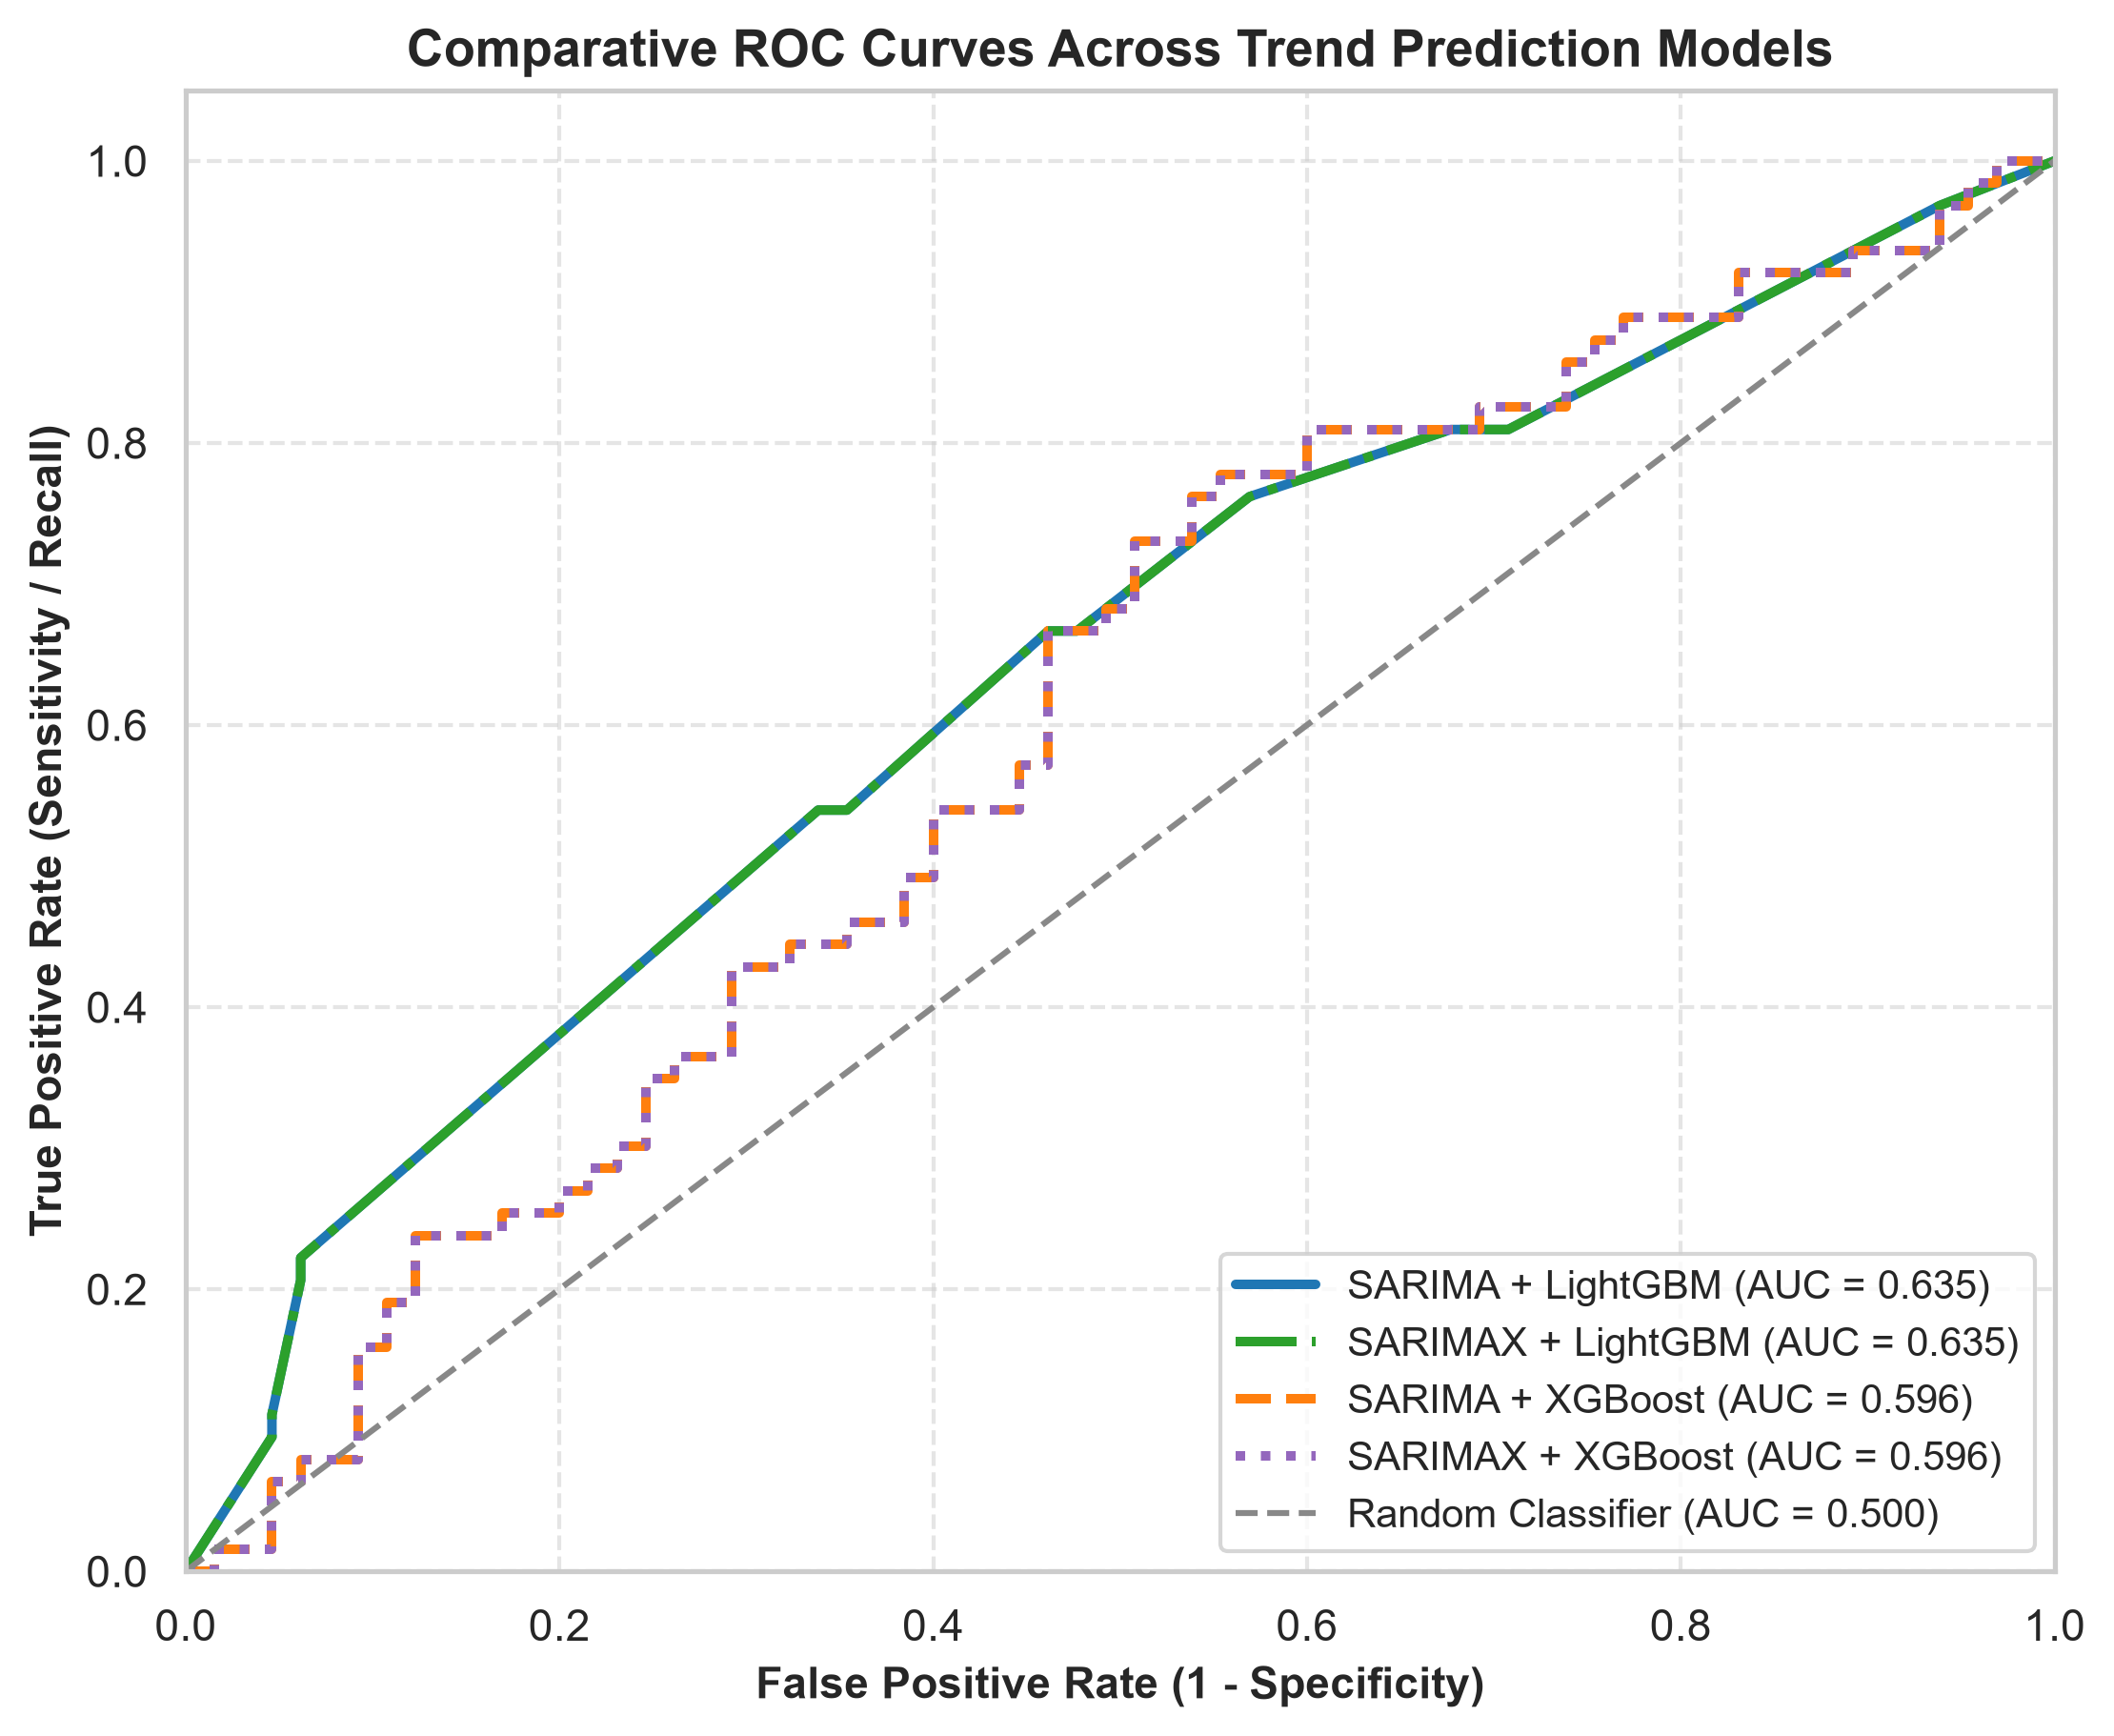


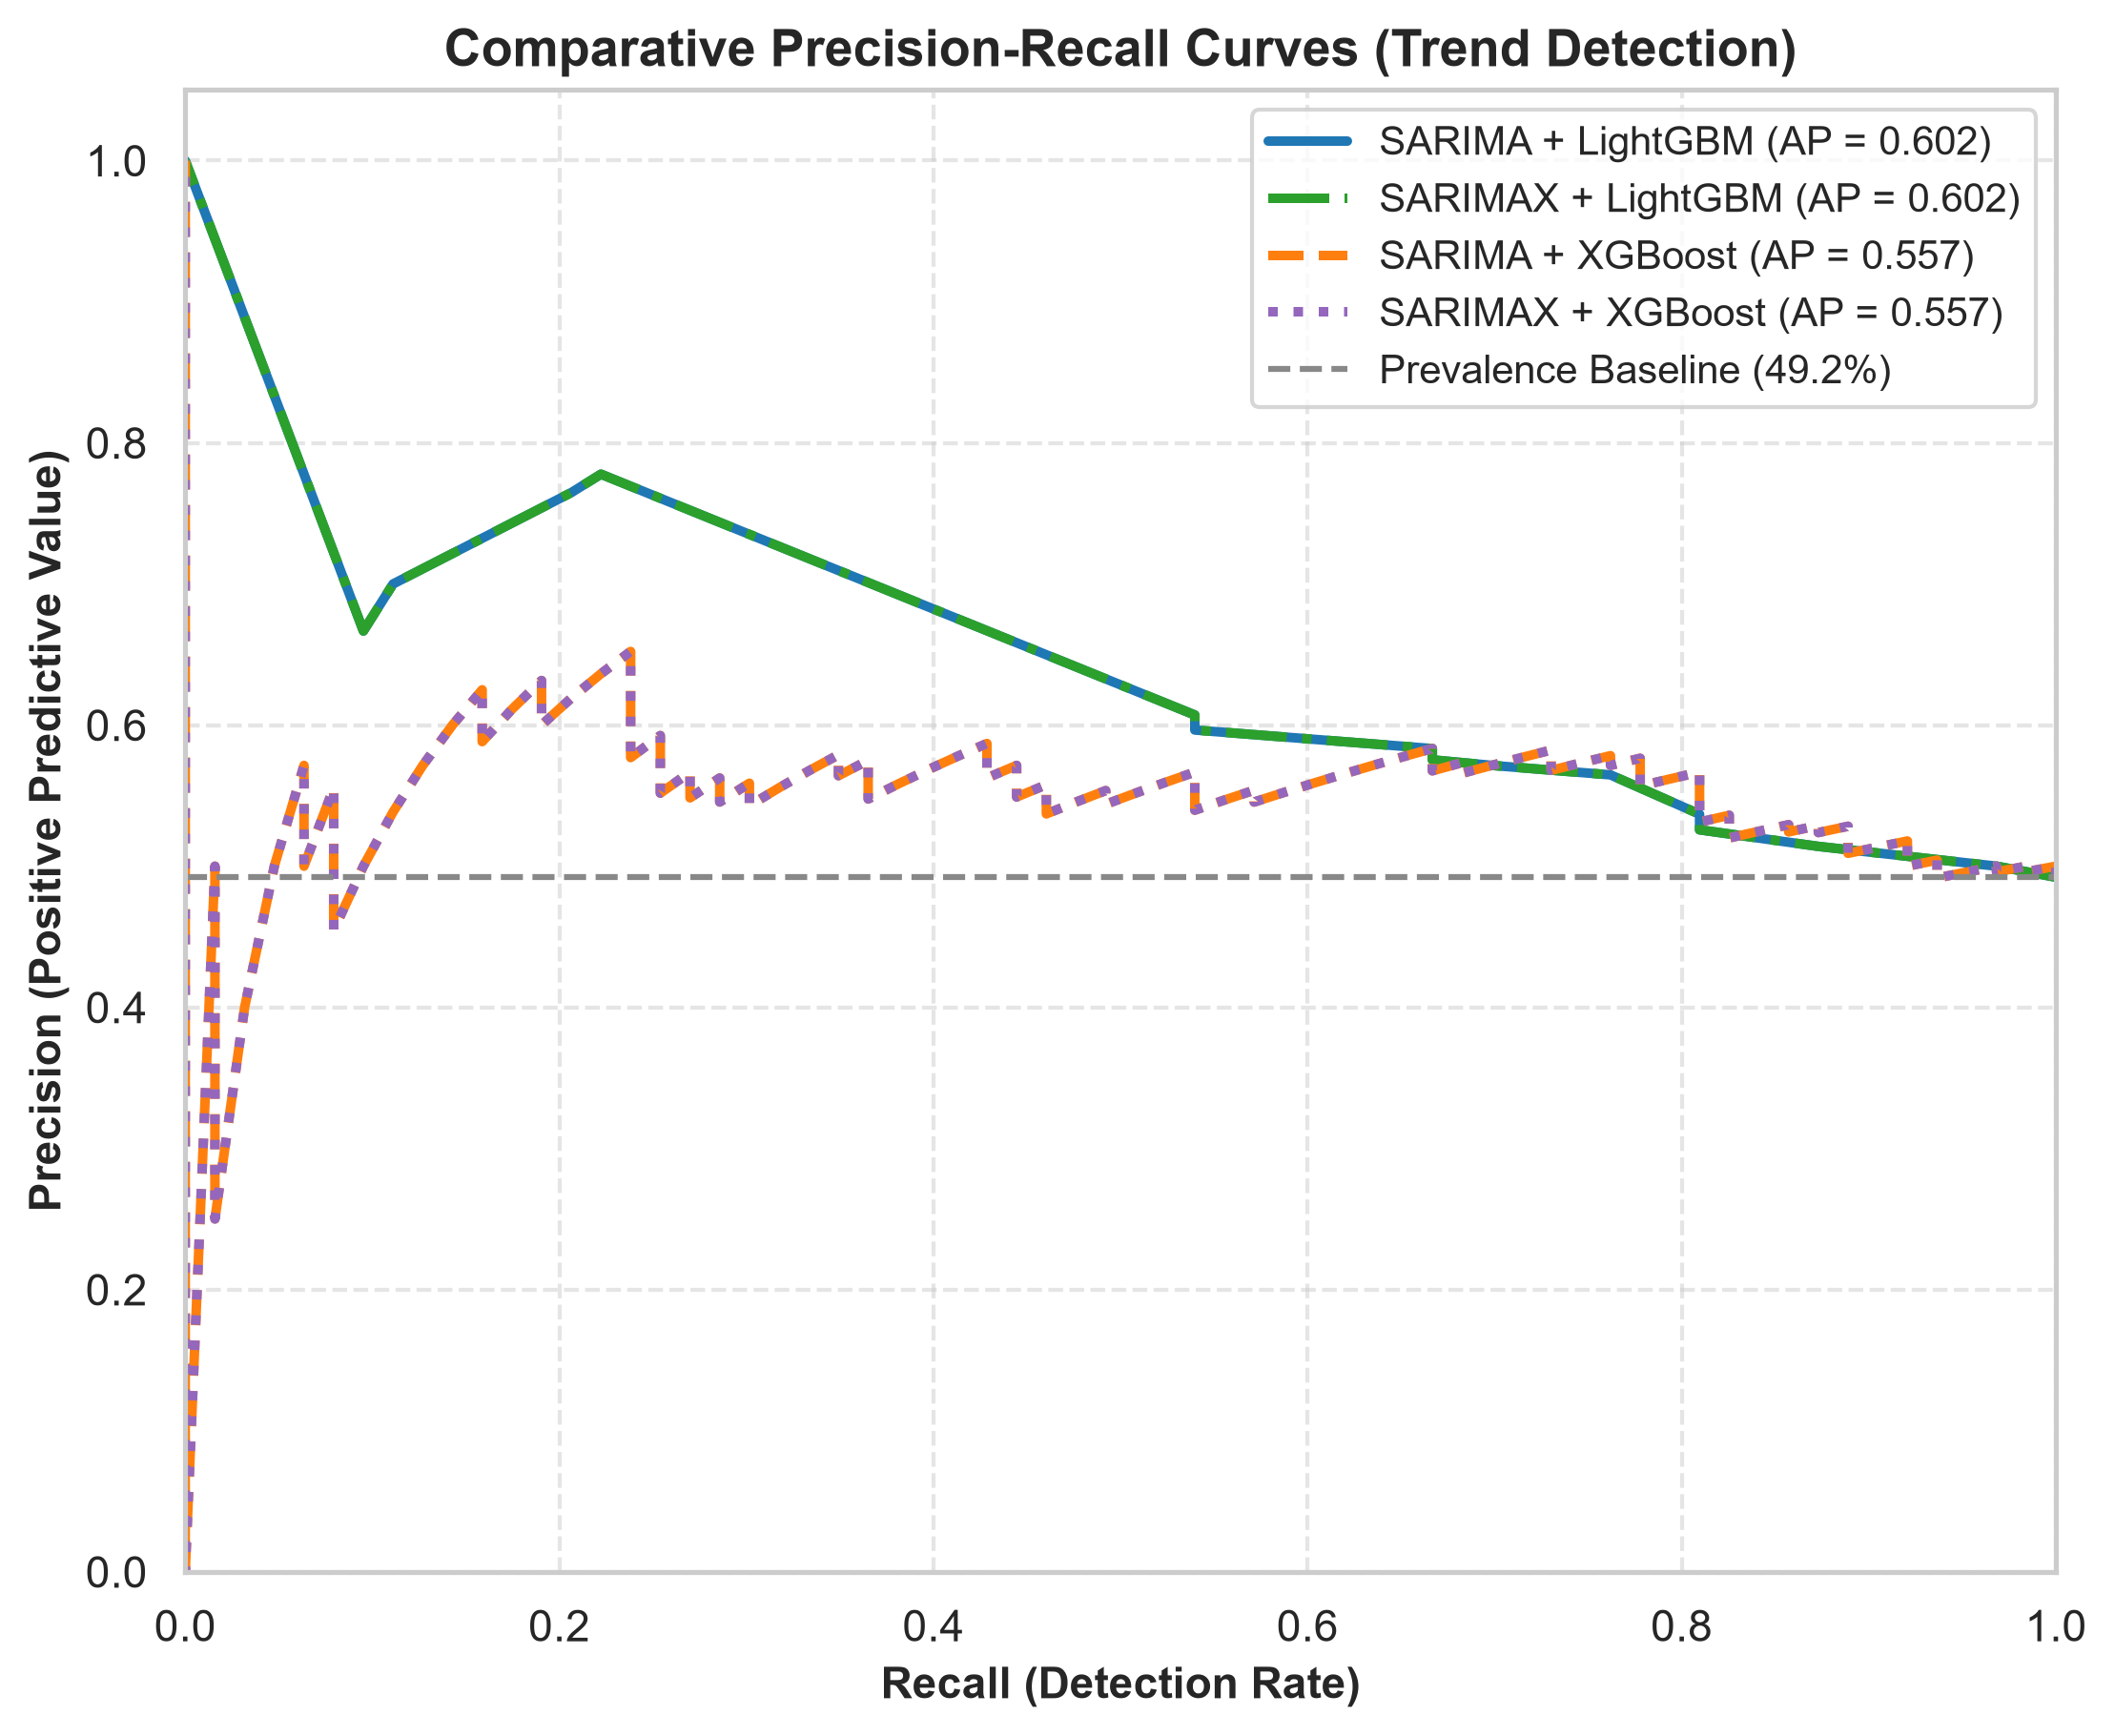


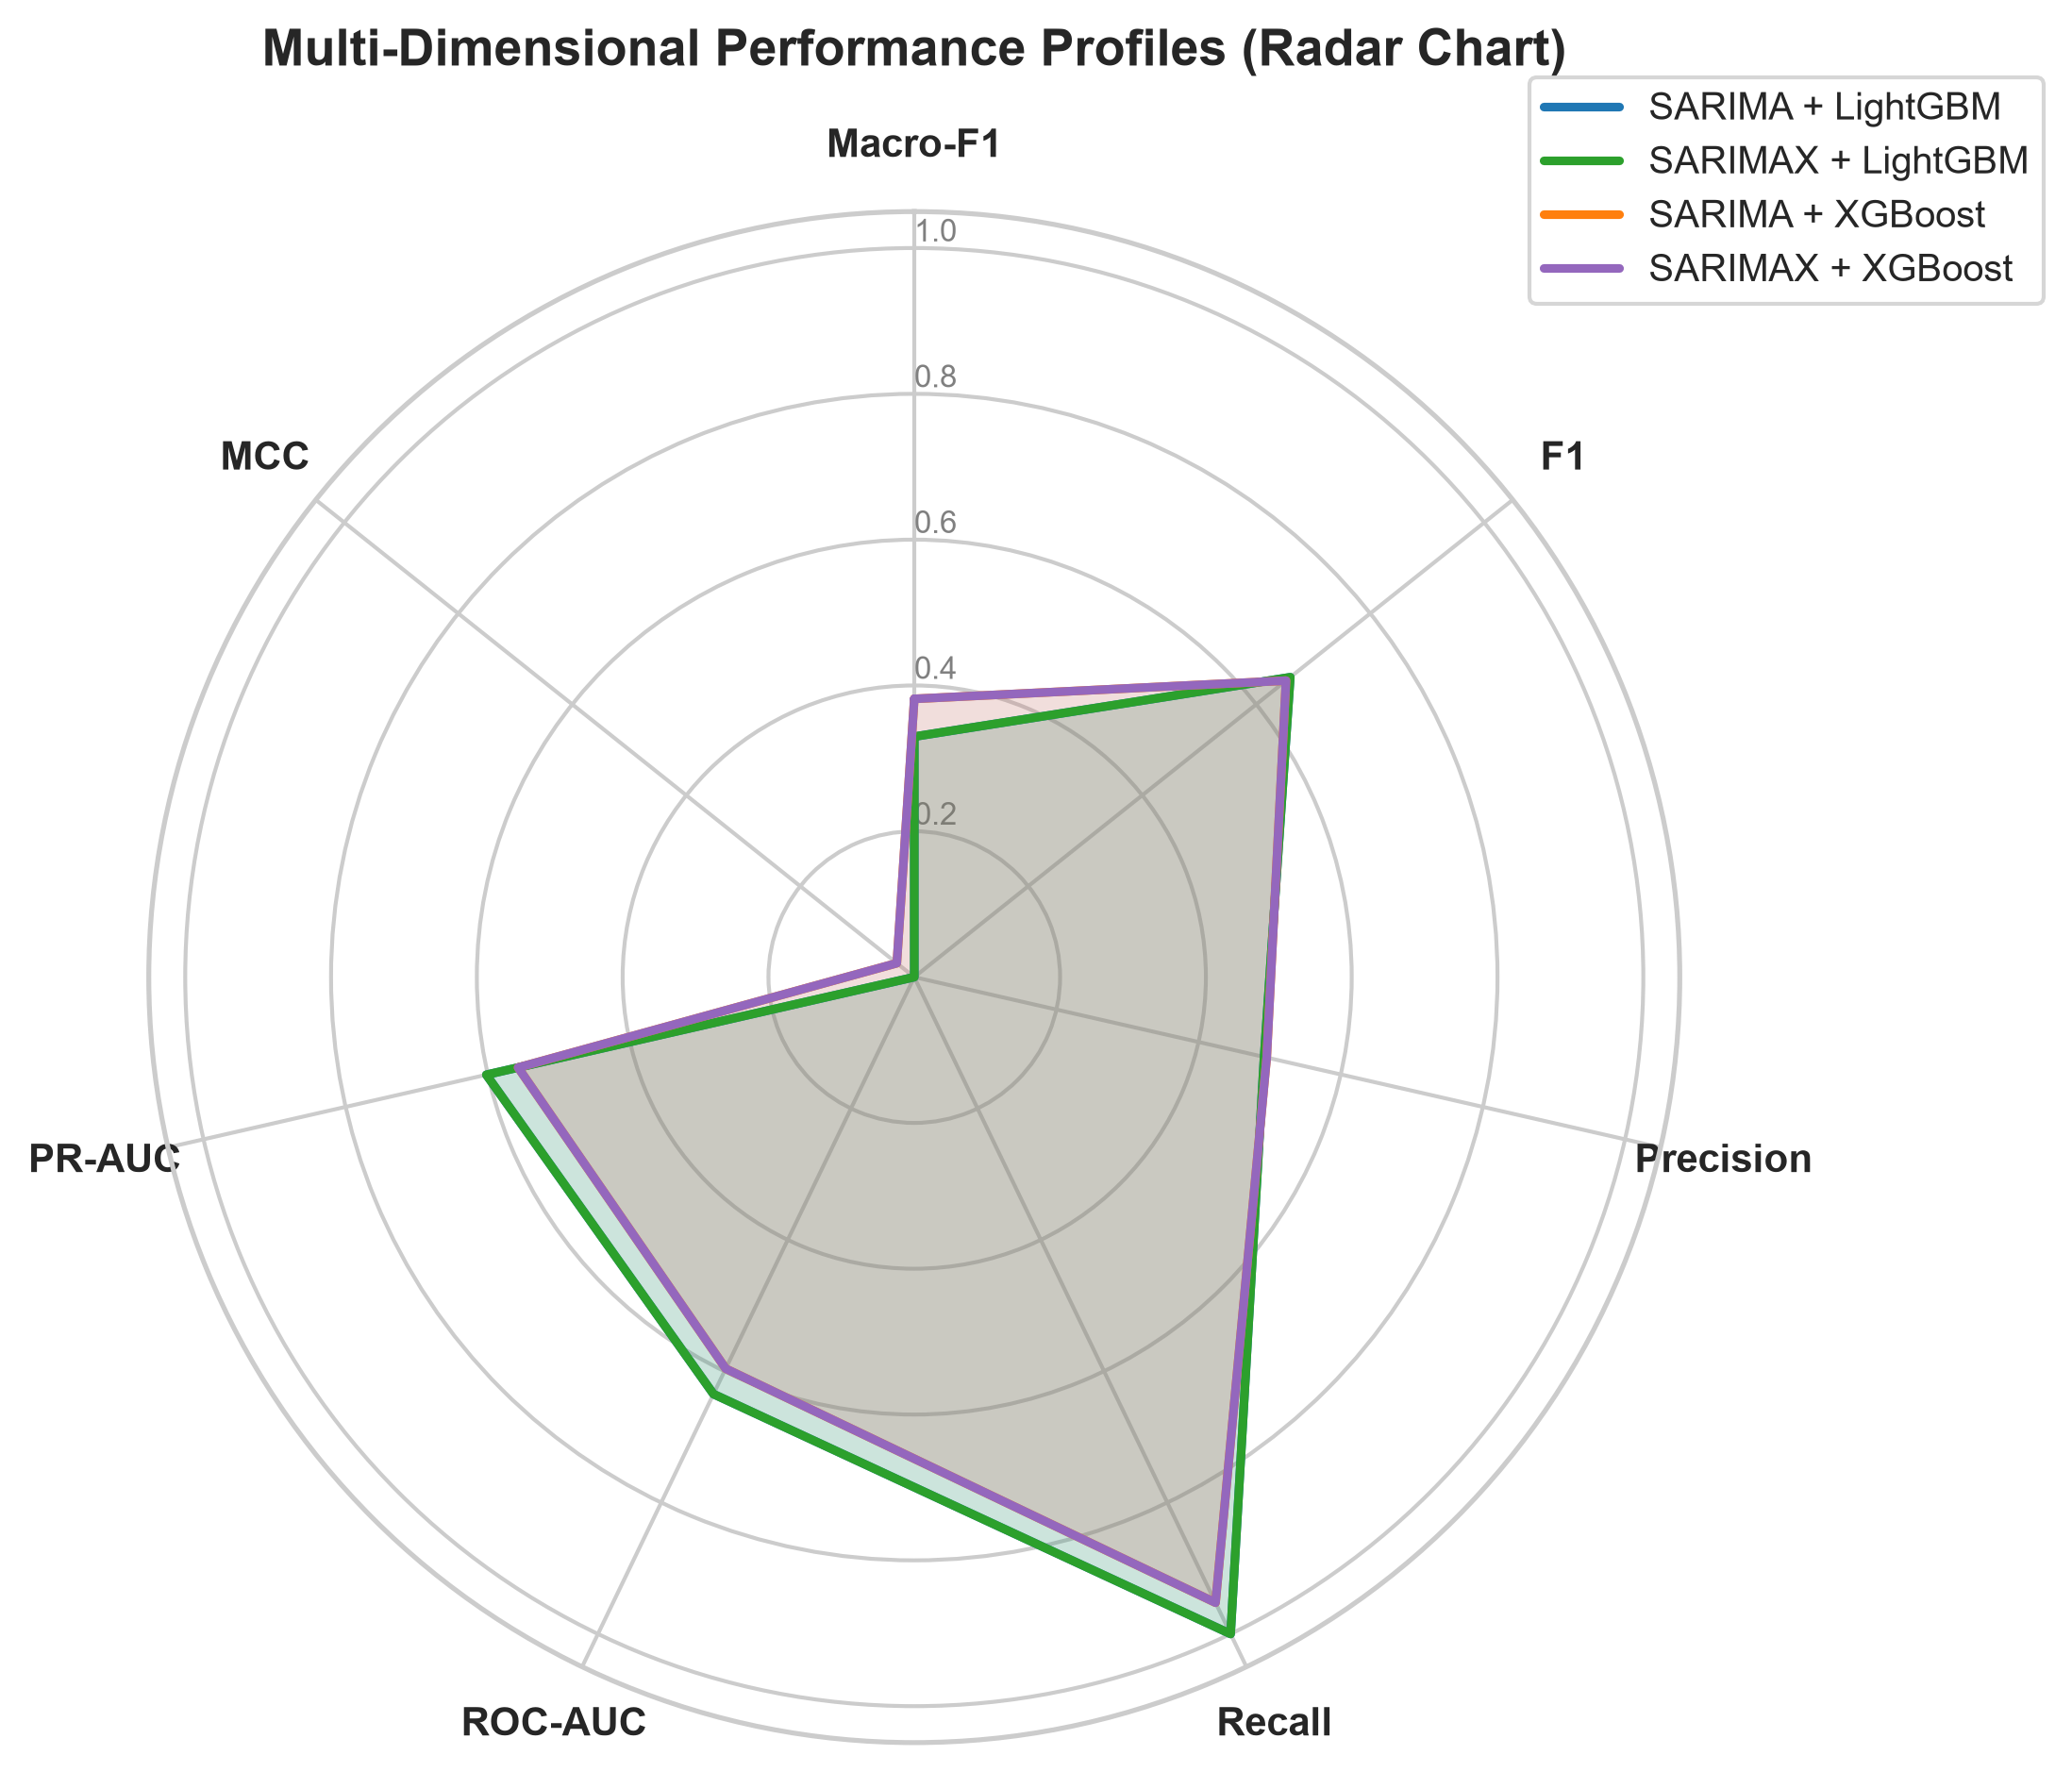


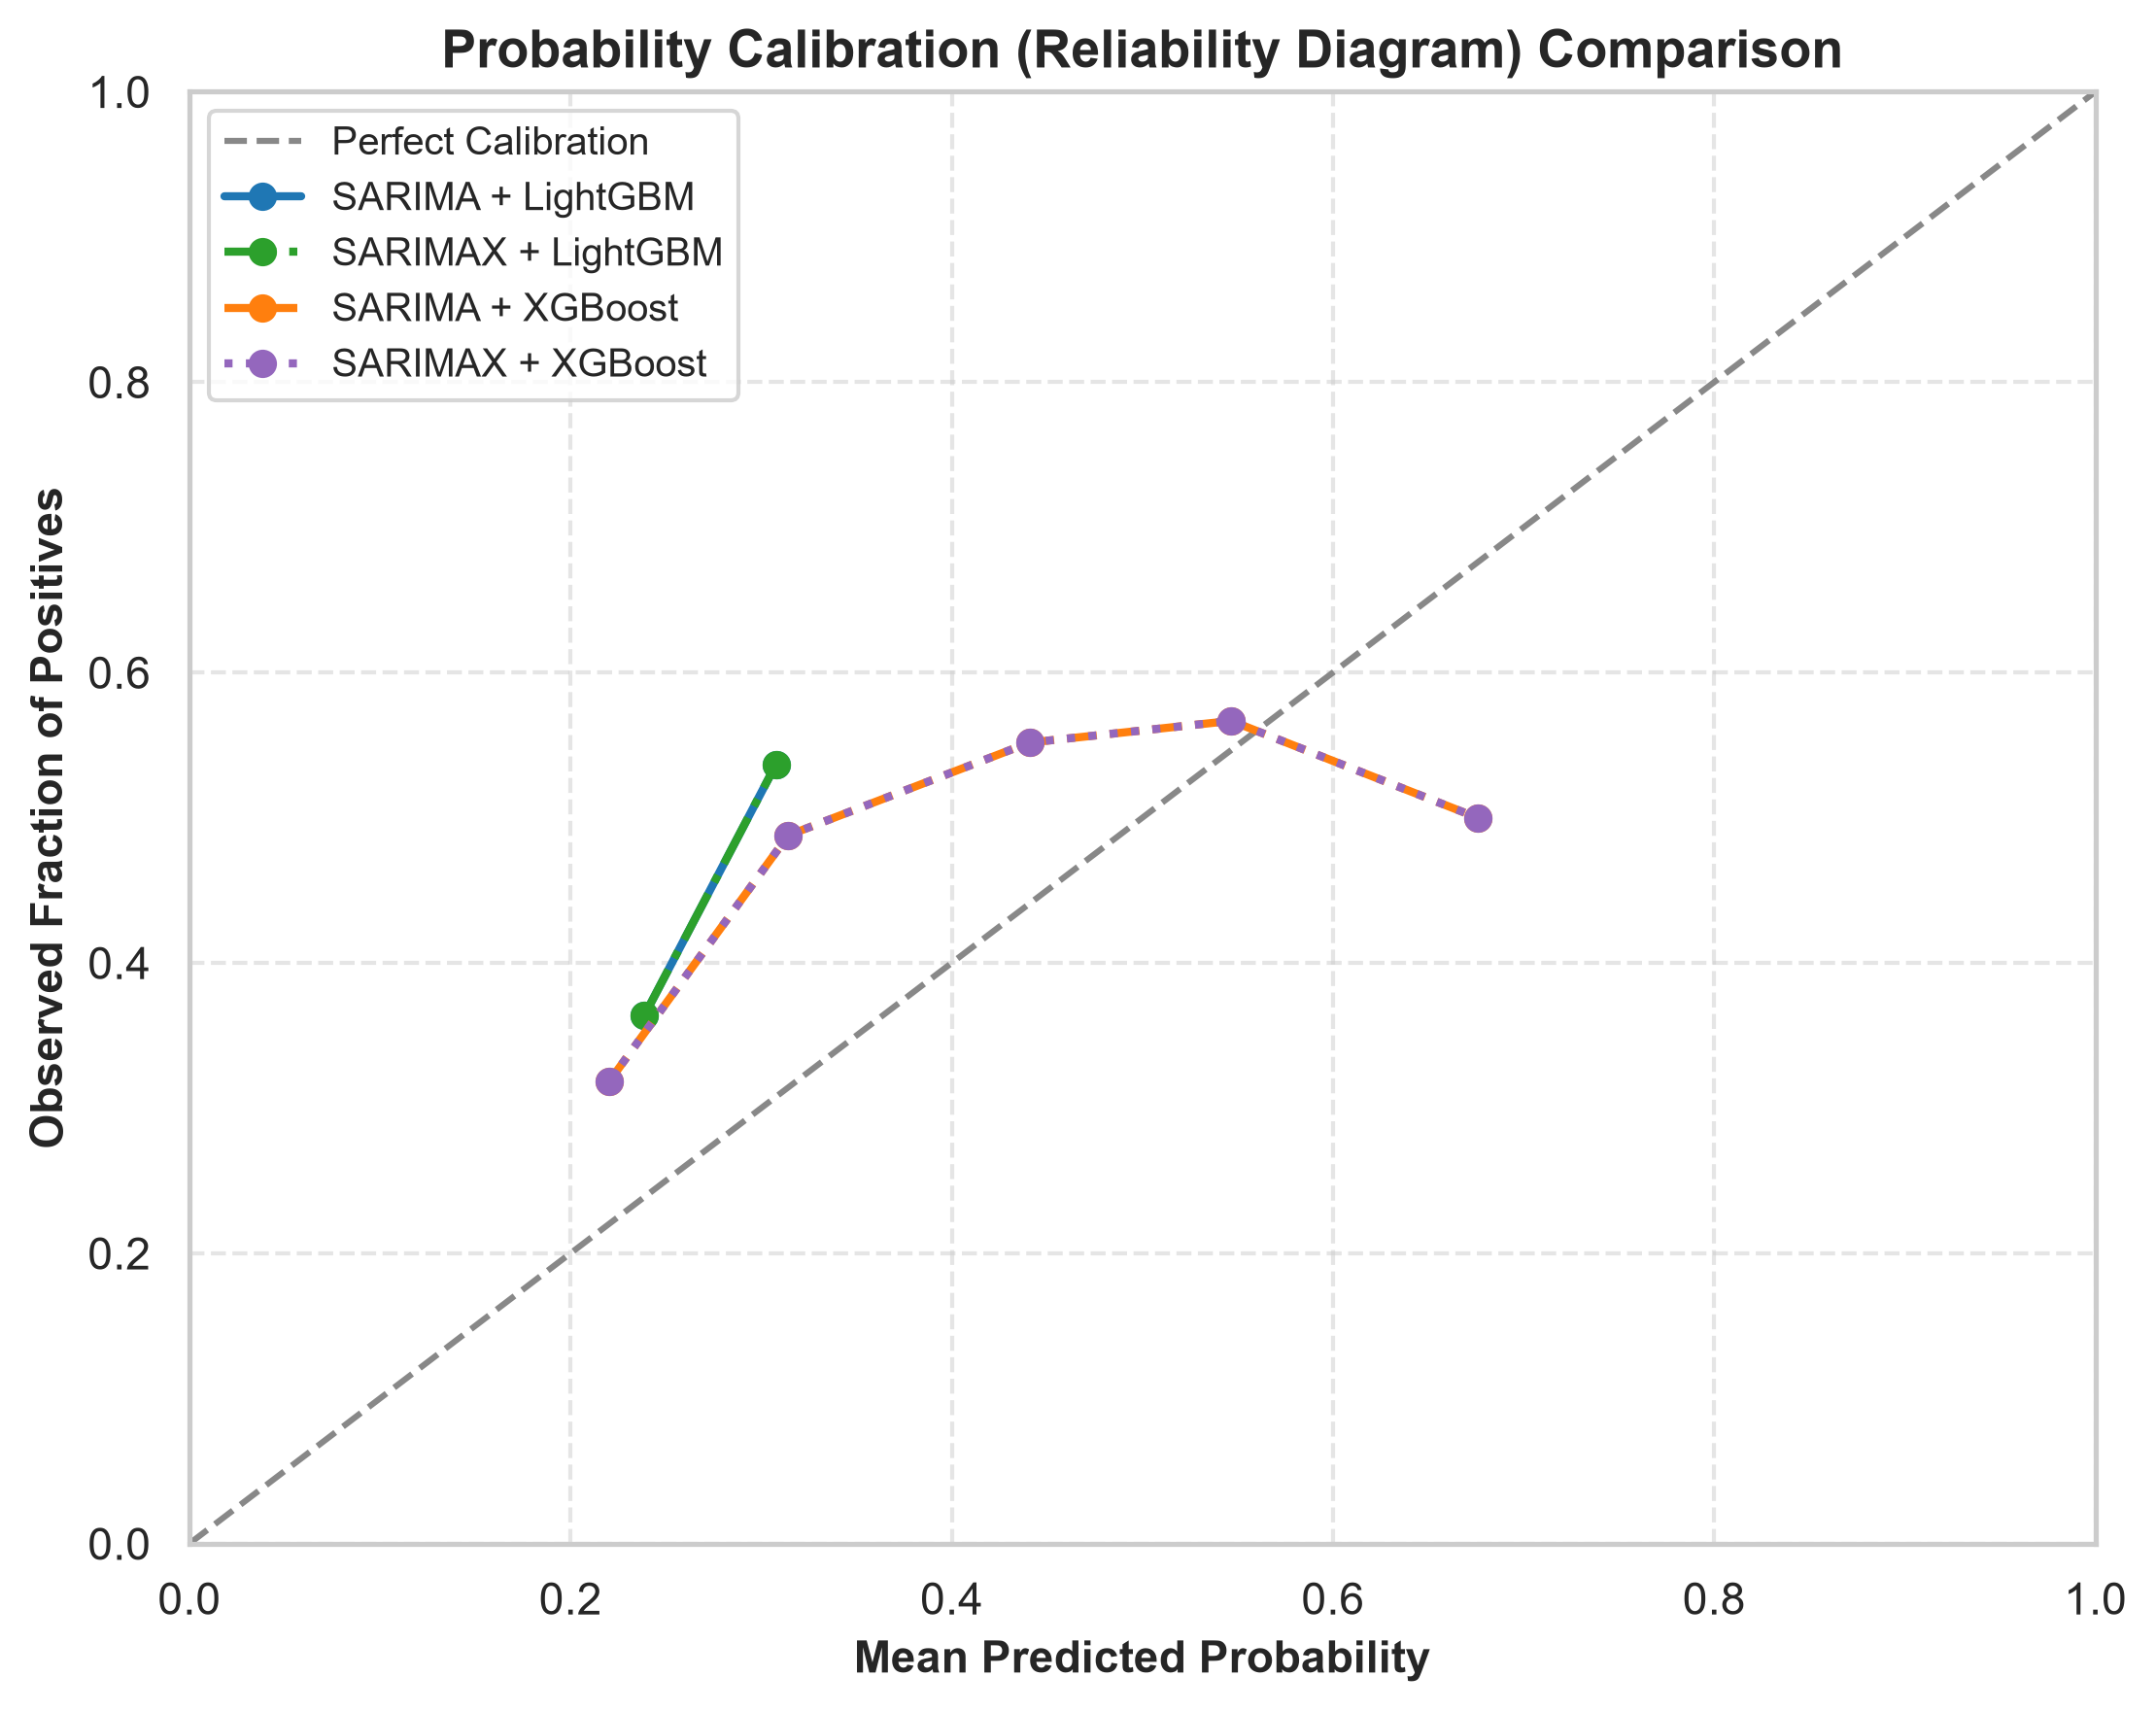


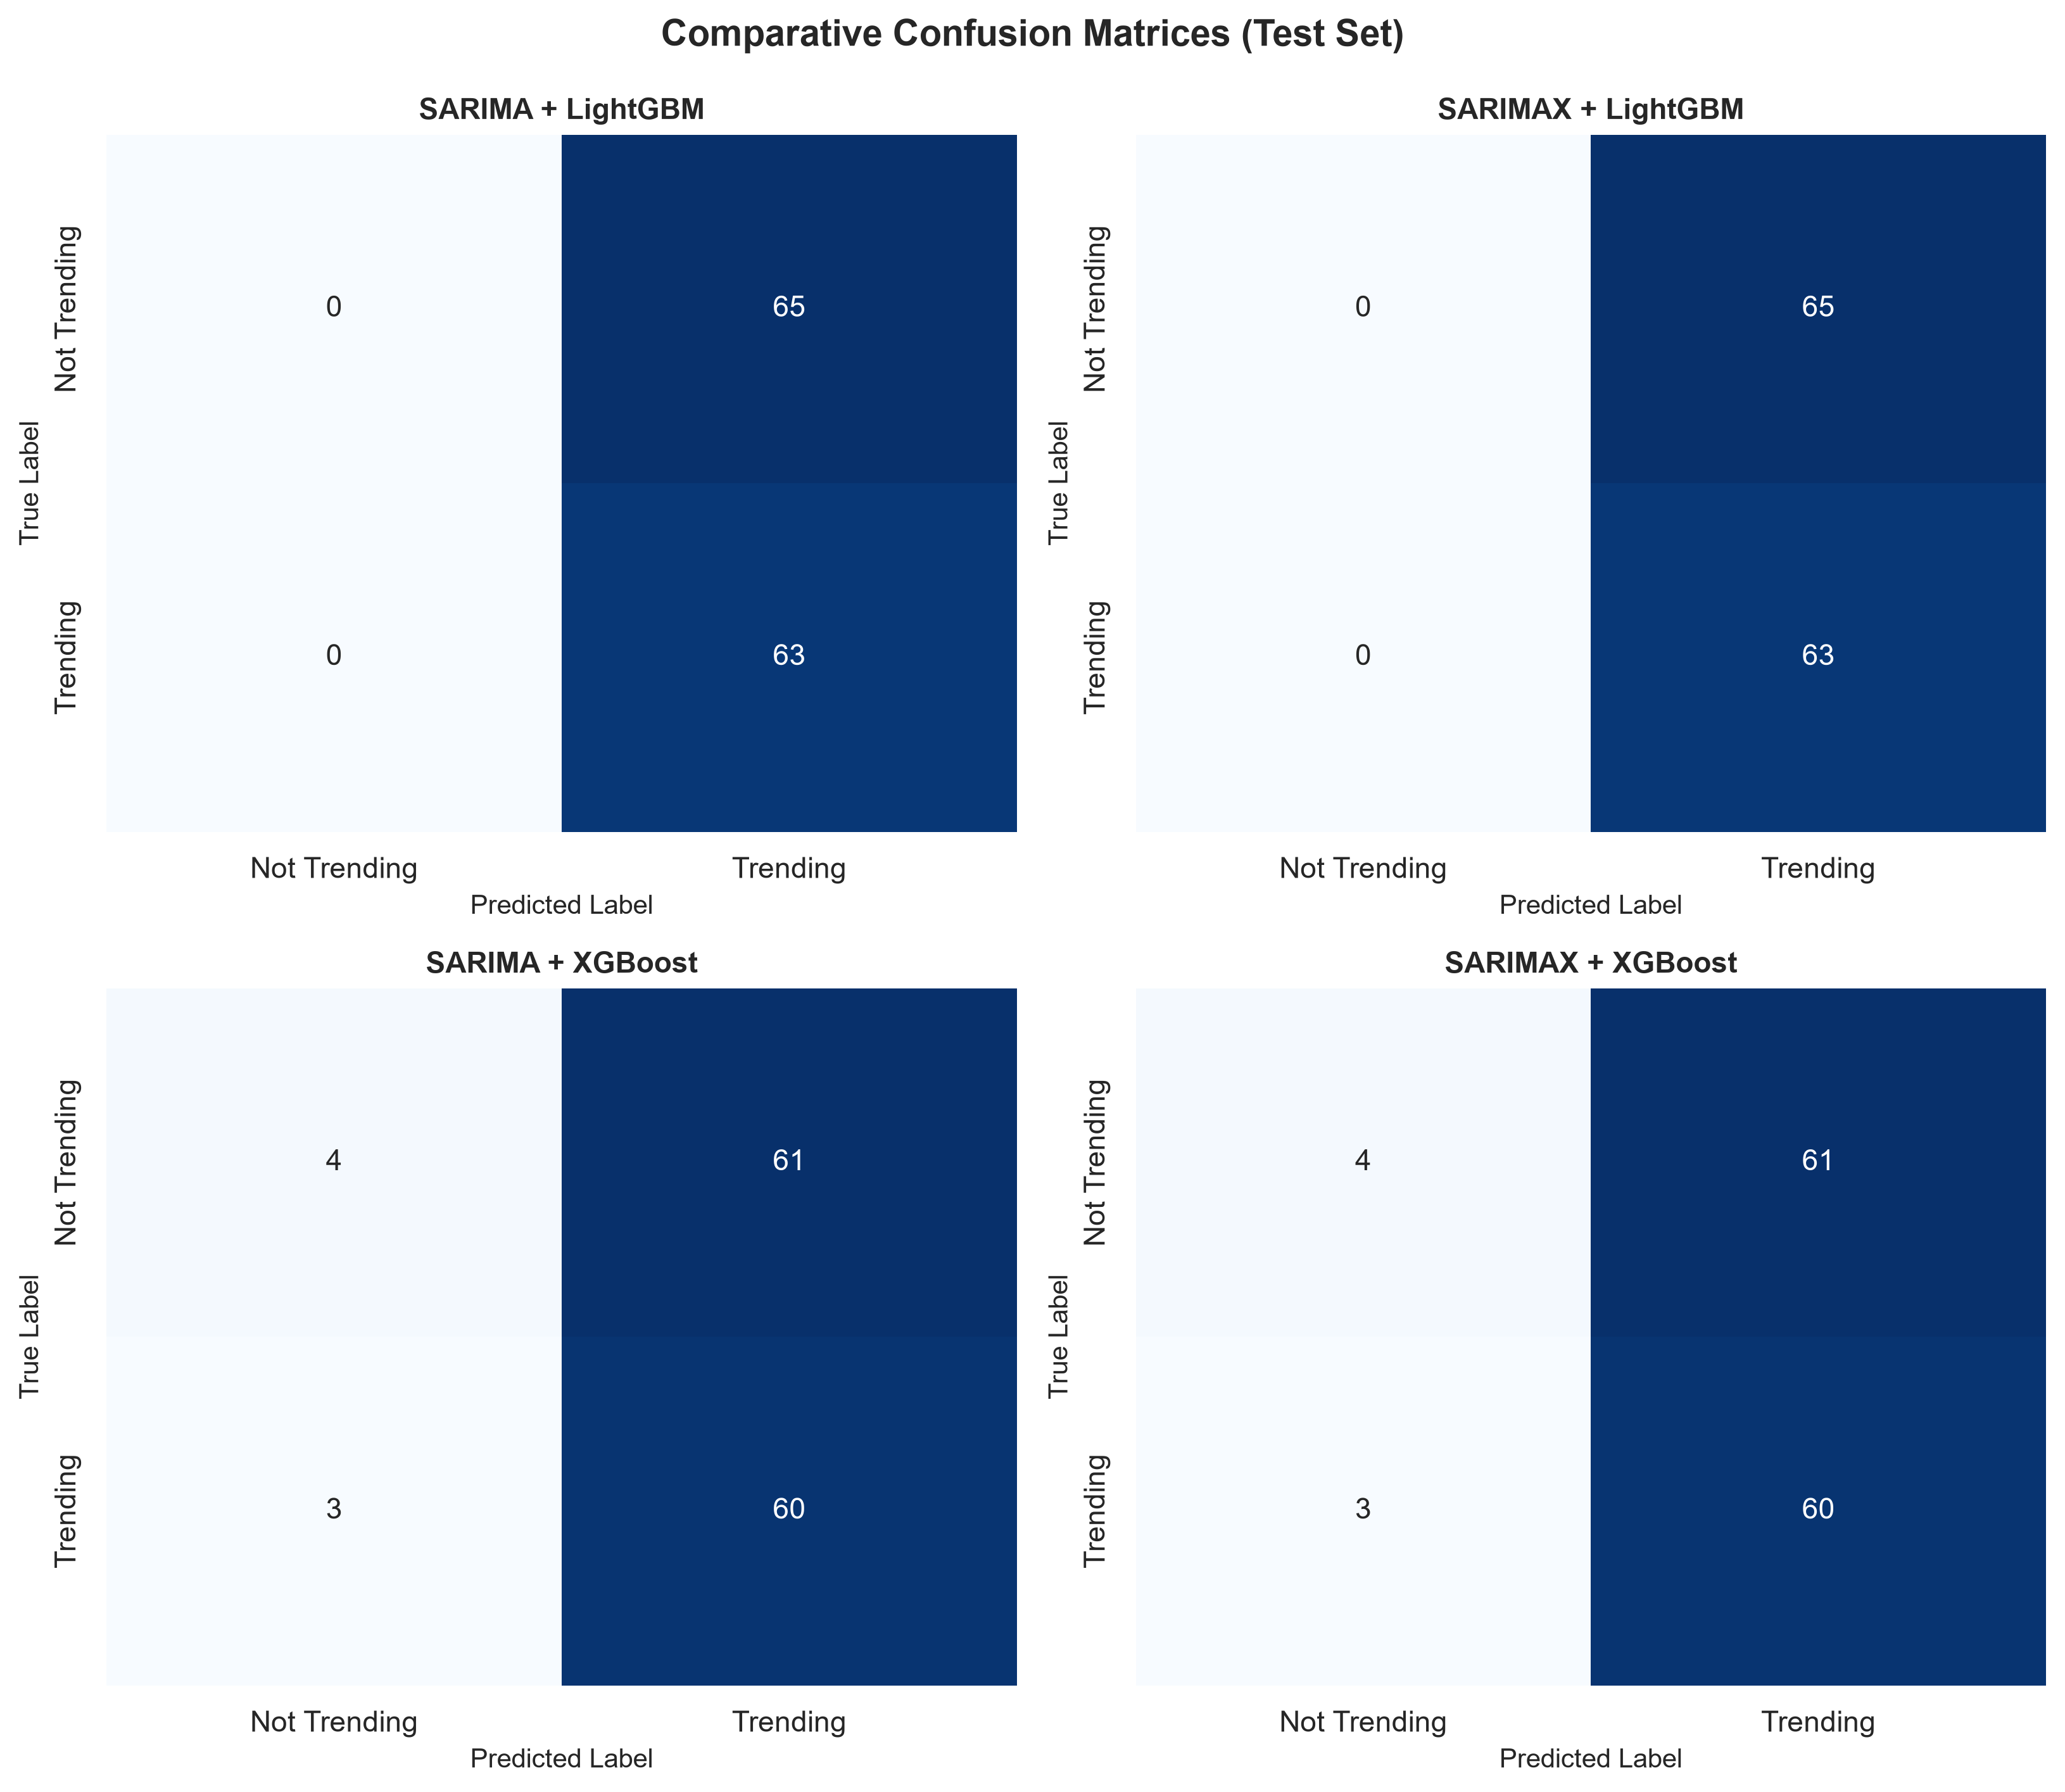


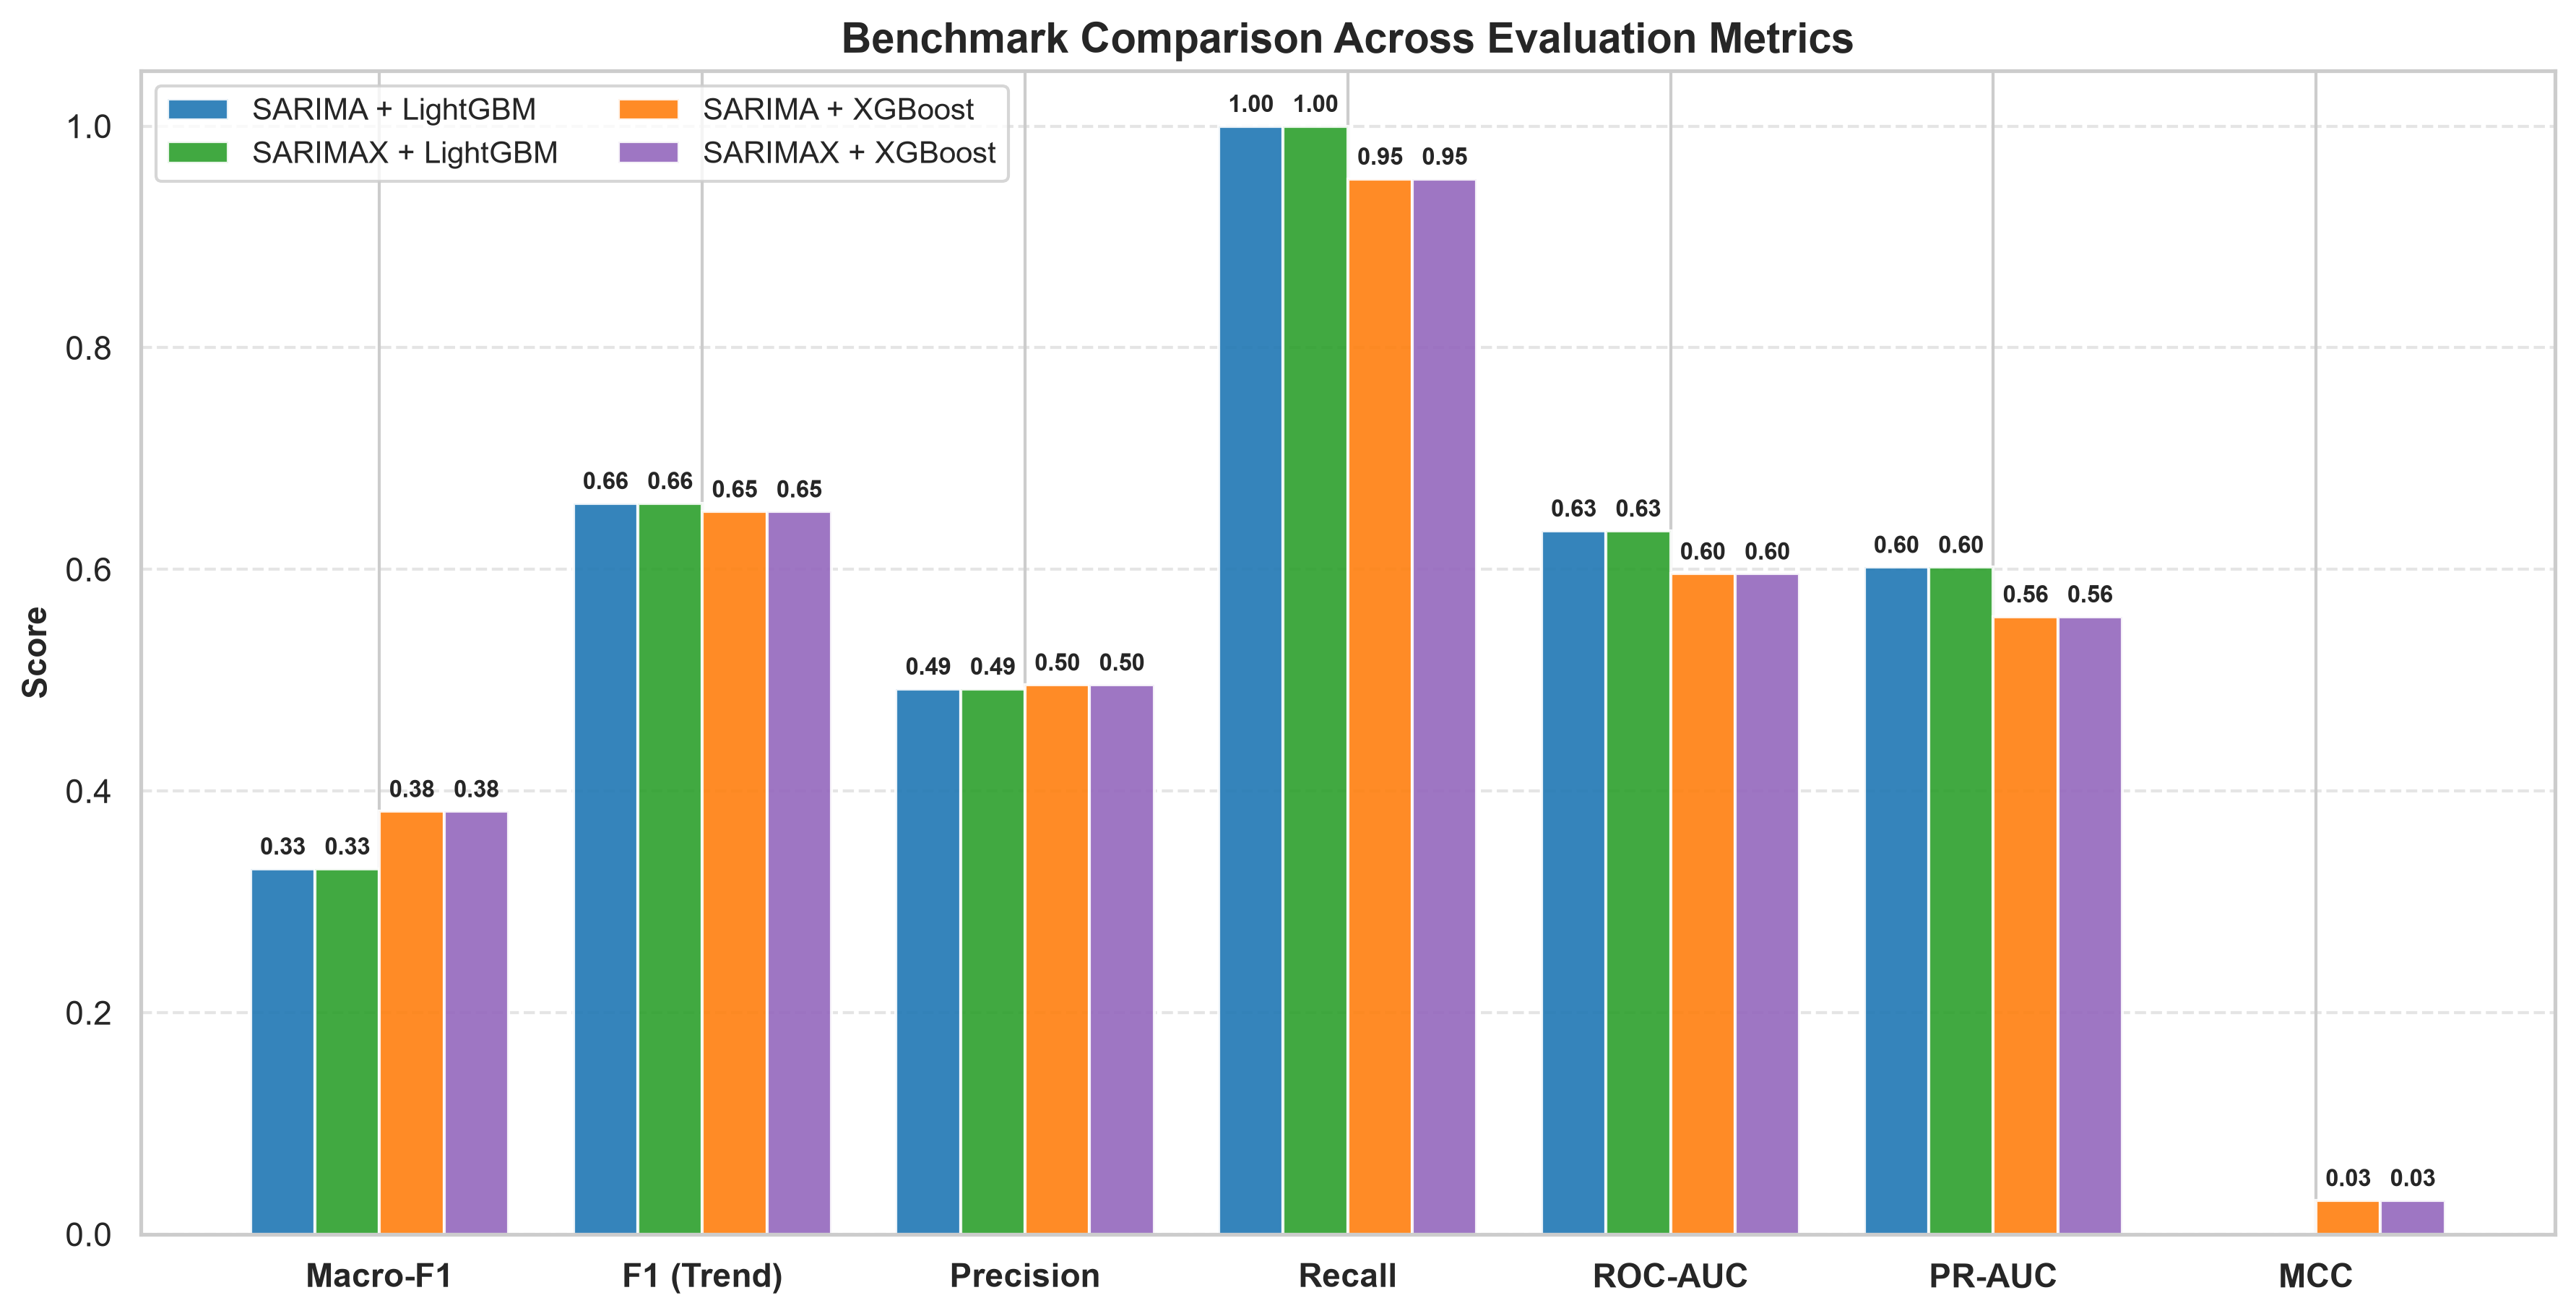

In [ ]:
import base64
import os
from IPython.display import HTML, display

def display_image_b64(title, img_path):
    if not os.path.exists(img_path):
        print(f"Plot not found: {img_path}")
        return
    with open(img_path, 'rb') as f:
        encoded = base64.b64encode(f.read()).decode('utf-8')
    html_code = f'''
    <div style="margin: 15px 0;">
        <h4 style="margin-bottom: 8px; color: #ffffff; font-family: sans-serif;">{title}</h4>
        <img src="data:image/png;base64,{encoded}" 
             style="max-width: 750px; width: 100%; border-radius: 8px; border: 1px solid #d2d6dc; box-shadow: 0 4px 12px rgba(0,0,0,0.08);" />
    </div>
    '''
    display(HTML(html_code))

comparison_plots = [
    ('ROC Curves', 'docs/images/model_comparison_roc.png'),
    ('Precision-Recall Curves', 'docs/images/model_comparison_pr.png'),
    ('Multi-Metric Radar Chart', 'docs/images/model_comparison_radar.png'),
    ('Calibration Curves (Reliability Diagram)', 'docs/images/model_comparison_calibration.png'),
    ('Confusion Matrix Grid', 'docs/images/model_comparison_confusion_matrices.png'),
    ('Metrics Barchart Comparison', 'docs/images/model_comparison_metrics_barchart.png')
]

for title, path in comparison_plots:
    display_image_b64(title, path)


--- 
## 5. Top Predicted Emerging & Trending Topics (24-Hour Horizon & Lifespan)

Ranking topics predicted as viral/emerging trends along with 24-hour survival likelihood and estimated persistence.

In [15]:
if os.path.exists(top_trending_path):
    df_top = pd.read_csv(top_trending_path)
    print(f"Total Emerging Trending Topics Identified: {len(df_top)}")
    
    candidate_cols = [
        'topic_id', 'topic_name', 'trending_probability', 'prob_trending_24h',
        'trend_status_24h', 'estimated_duration_days', 'trend_lifespan', 'persistence_score'
    ]
    show_cols = [c for c in candidate_cols if c in df_top.columns]
    display_df = df_top[show_cols].head(10)
    display(display_df)
else:
    print(f"{top_trending_path} not found.")

Total Emerging Trending Topics Identified: 121


,topic_id,topic_name,trending_probability,prob_trending_24h,trend_status_24h,estimated_duration_days,trend_lifespan,persistence_score
0,2,2_the_oscars_of_her,0.736381,0.5695,Sustained Trending (> 24h),5.0,>= 3 Days (Sustained),77.3
1,0,0_the_league_city_in,0.686678,0.5311,Sustained Trending (> 24h),5.0,>= 3 Days (Sustained),77.3
2,32,32_thread_post_match_discussion,0.685418,0.5301,Sustained Trending (> 24h),5.0,>= 3 Days (Sustained),77.3
3,12,12_sports_sky_subscribe_premier,0.662815,0.5126,Sustained Trending (> 24h),5.0,>= 3 Days (Sustained),77.3
4,8,8_my_it_and_when,0.655453,0.6334,Sustained Trending (> 24h),5.0,>= 3 Days (Sustained),96.6
5,17,17_perks_membersonly_variety_join,0.627784,0.4945,Sustained Trending (> 24h),5.0,>= 3 Days (Sustained),78.8
6,11,11_arsenal_chances_goal_vs,0.618033,0.4780,Sustained Trending (> 24h),5.0,>= 3 Days (Sustained),77.3
7,1,1_comments_link_submitted_by,0.591636,0.4609,Sustained Trending (> 24h),5.0,>= 3 Days (Sustained),77.9
8,37,37_comments_chinese_link_submitted,0.585018,0.5462,Sustained Trending (> 24h),5.0,>= 3 Days (Sustained),93.4
9,23,23_game_boss_and_elden,0.584388,0.4520,Sustained Trending (> 24h),5.0,>= 3 Days (Sustained),77.3


--- 
## 6. LaTeX Academic Table Export

The table below is formatted directly for inclusion in academic publications and research papers (saved at `data/08_predictions/model_comparison_table.tex`).

In [16]:
import os
from IPython.display import Markdown, display

tex_path = 'data/08_predictions/model_comparison_table.tex'
if os.path.exists(tex_path):
    with open(tex_path, 'r', encoding='utf-8') as f:
        tex_content = f.read()
    
    display(Markdown('### 📊 Bảng đối sánh hiệu năng các mô hình (Summary View):'))
    display(comp_df[valid_cols].rename(columns=lambda c: c.replace('_', ' ').title()))
    
    display(Markdown(f'''
---
#### 📝 Mã nguồn LaTeX (Sẵn sàng copy dán vào Overleaf / Báo cáo NCKH):
```latex
{tex_content}
```
'''))
else:
    print(f"{tex_path} not found.")


### 📊 Bảng đối sánh hiệu năng các mô hình (Summary View):

,Model Name,Macro F1,F1 Score,Roc Auc,Pr Auc,Mcc,Brier Score,Recall At 10Pct,Recall At 20Pct
0,SARIMA + LightGBM,0.329843,0.659686,0.634799,0.602035,0.000000,0.285370,0.142857,0.253968
1,SARIMAX + LightGBM,0.329843,0.659686,0.634799,0.602035,0.000000,0.285370,0.142857,0.253968
2,SARIMA + XGBoost,0.381643,0.652174,0.596093,0.557385,0.030606,0.256893,0.095238,0.238095
3,SARIMAX + XGBoost,0.381643,0.652174,0.596093,0.557385,0.030606,0.256893,0.095238,0.238095



---
#### 📝 Mã nguồn LaTeX (Sẵn sàng copy dán vào Overleaf / Báo cáo NCKH):
```latex
\begin{table}[htbp]
\centering
\caption{Comprehensive Performance Comparison of Hybrid Trend Prediction Frameworks}
\label{tab:model_comparison}
\resizebox{\textwidth}{!}{
\begin{tabular}{lcccccccc}
\hline\hline
Model Name & Macro F1 & F1 Score & Precision & Recall & Roc Auc & Pr Auc & Mcc & Optimal Threshold \\
\hline
SARIMA + LightGBM & 0.3298 & 0.6597 & 0.4922 & 1.0000 & 0.6348 & 0.6020 & 0.0000 & 0.0500 \\
SARIMAX + LightGBM & 0.3298 & 0.6597 & 0.4922 & 1.0000 & 0.6348 & 0.6020 & 0.0000 & 0.0500 \\
SARIMA + XGBoost & 0.3816 & 0.6522 & 0.4959 & 0.9524 & 0.5961 & 0.5574 & 0.0306 & 0.2100 \\
SARIMAX + XGBoost & 0.3816 & 0.6522 & 0.4959 & 0.9524 & 0.5961 & 0.5574 & 0.0306 & 0.2100 \\
\hline\hline
\end{tabular}
}
\end{table}
```
